In [2]:
import numpy as np
import matplotlib.pyplot as plt

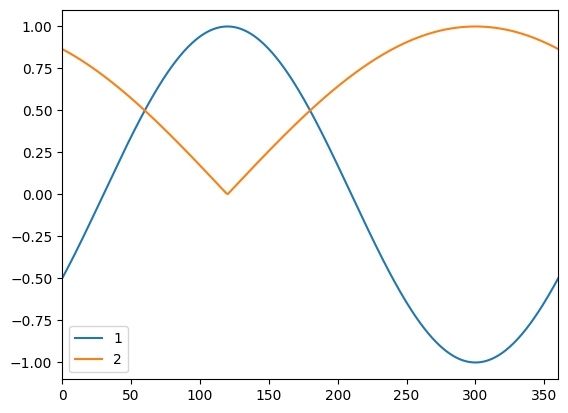

In [52]:
car_angle = np.linspace(0, 360, num=360)
angle_to_checkpoint = 120
reward = np.cos(np.radians(car_angle - angle_to_checkpoint))
reward2 = abs(np.sin(np.radians(car_angle - angle_to_checkpoint) / 2))

plt.plot(car_angle, reward, label='1')
plt.plot(car_angle, reward2, label='2')
plt.xlim([0, 360])
plt.legend()

In [12]:
sin_vals = np.linspace(-1, 1, num=9)
to_dig = list(np.random.random(10) * 3 - 1.5)
print(to_dig)
np.digitize([0.5], sin_vals)

[np.float64(-1.2187158039215344), np.float64(-0.2163645823734046), np.float64(1.3620836895558481), np.float64(-0.9819863530520048), np.float64(-0.25212397373690654), np.float64(-1.2911016725354227), np.float64(-0.6742641682367199), np.float64(-0.4323791798099048), np.float64(1.278114387108281), np.float64(1.0070402237044878)]


array([7])

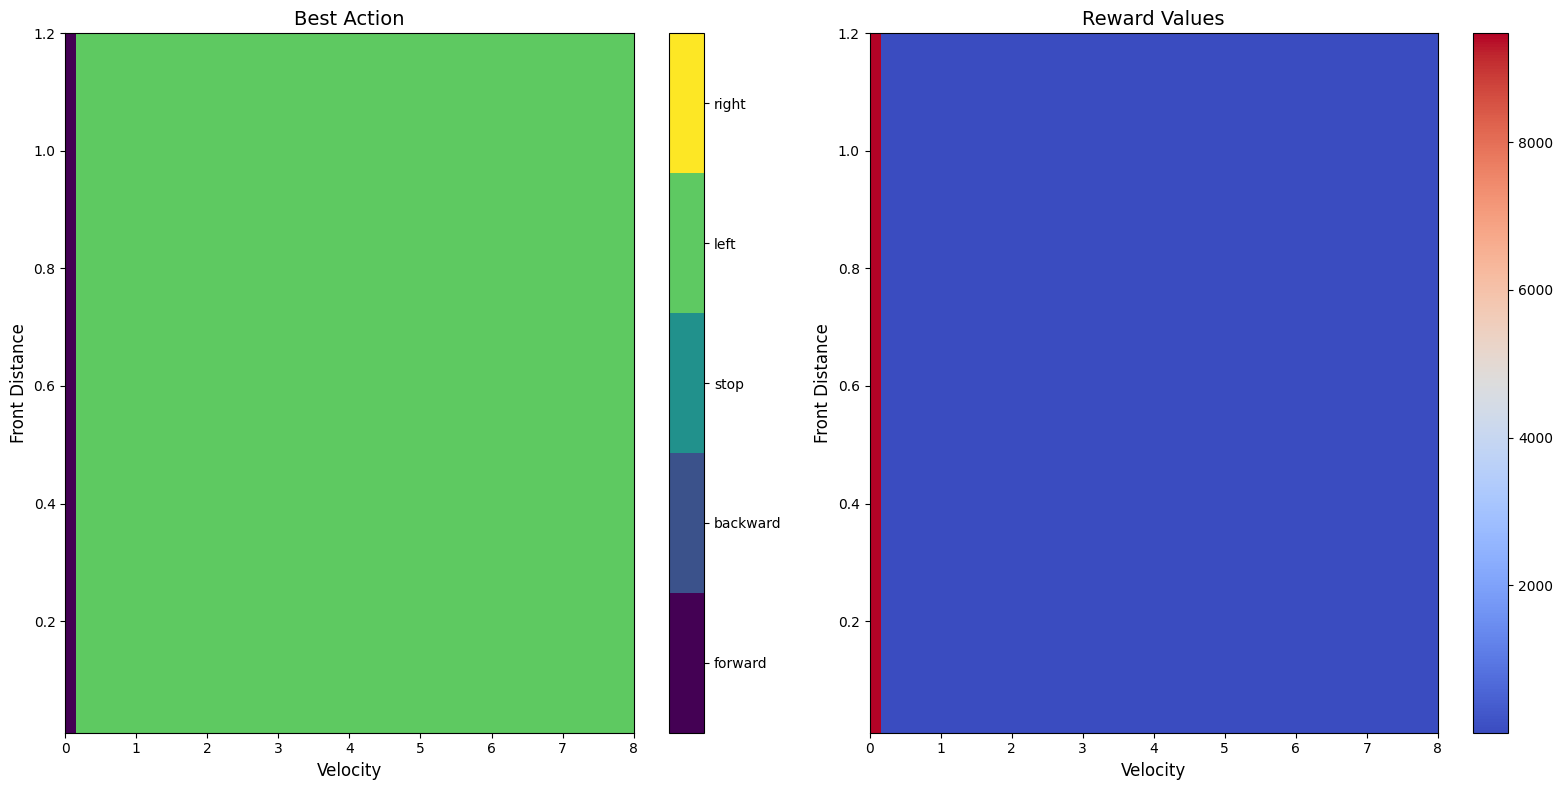

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from importlib import reload
from constants import *
import approximation

reload(approximation)

class MockCar:
        def __init__(self, vel):
                self.vel = vel
                self.to_plot_dict = defaultdict(list)

res_v=50
res_d=50
actions = ['forward', 'backward', 'stop', 'left', 'right']
vels = np.linspace(0, 8.0, res_v)
dists = np.linspace(0.01, 1.2, res_d)
policy_grid = np.zeros((res_d, res_v))
reward_grid = np.zeros((res_d, res_v))

for i, d in enumerate(dists):
        for j, v in enumerate(vels):
                car = MockCar(v)
                previous_action = 'left'
                state=[np.array([0.075, 0.53 , 0.385, 0.305, 0.29 ]), np.array([1., 1., 1., 1., 1.]), np.float64(0.91), v]
                cos = 1 - 2 * (np.sign(state[2]) * abs(state[2])**(1/3))**2
                rewards = [approximation.action_rewards(state, a, cos, car, previous_action, show=False) for a in actions]
                policy_grid[i, j], reward_grid[i, j] = np.argmax(rewards), np.max(rewards)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Left plot - actions
n_actions = len(actions)
cmap = plt.get_cmap('viridis', n_actions)
im1 = ax1.imshow(policy_grid, origin='lower', aspect='auto', 
        extent=[vels[0], vels[-1], dists[0], dists[-1]],
        cmap=cmap, vmin=-0.5, vmax=n_actions - 0.5)
ax1.set_xlabel('Velocity', fontsize=12)
ax1.set_ylabel('Front Distance', fontsize=12)
ax1.set_title('Best Action', fontsize=14)
cbar1 = plt.colorbar(im1, ax=ax1, ticks=range(n_actions))
cbar1.ax.set_yticklabels(actions)

# Right plot - reward values
im2 = ax2.imshow(reward_grid, origin='lower', aspect='auto',
        extent=[vels[0], vels[-1], dists[0], dists[-1]],
        cmap='coolwarm')
ax2.set_xlabel('Velocity', fontsize=12)
ax2.set_ylabel('Front Distance', fontsize=12)
ax2.set_title('Reward Values', fontsize=14)
plt.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.show()

In [10]:
cases = [
    # (old_sin, new_sin, opis, oczekiwany: +/-)
    (0.4,  0.2,  "prawo -> ku 0",     "+"),
    (-0.4, -0.2, "lewo -> ku 0",      "+"),
    (0.2,  0.4,  "prawo -> od 0",     "-"),
    (-0.2, -0.4, "lewo -> od 0",      "-"),
    (0.05, -0.05,"przez 0",           "-"),
    (-0.05, 0.05,"przez 0",           "-"),
    (0.3,  0.295,"zmiana za mala",    "0"),
]

for old_sin, new_sin, opis, oczek in cases:
    reward = 0.0
    sin_diff = old_sin - new_sin

    if np.sign(sin_diff) == np.sign(old_sin):
        reward += abs(sin_diff) * 3.5
    elif abs(sin_diff) > 2e-2:
        reward -= abs(sin_diff) * 4.0

    ok = (oczek == "+" and reward > 0) or \
            (oczek == "-" and reward < 0) or \
            (oczek == "0" and reward == 0)

    print(f"{'OK' if ok else 'FAIL'} | {opis:<20} | old={old_sin:>6.3f} new={new_sin:>6.3f} | reward={reward:>7.4f} | oczek={oczek}")


OK | prawo -> ku 0        | old= 0.400 new= 0.200 | reward= 0.7000 | oczek=+
OK | lewo -> ku 0         | old=-0.400 new=-0.200 | reward= 0.7000 | oczek=+
OK | prawo -> od 0        | old= 0.200 new= 0.400 | reward=-0.8000 | oczek=-
OK | lewo -> od 0         | old=-0.200 new=-0.400 | reward=-0.8000 | oczek=-
FAIL | przez 0              | old= 0.050 new=-0.050 | reward= 0.3500 | oczek=-
FAIL | przez 0              | old=-0.050 new= 0.050 | reward= 0.3500 | oczek=-
FAIL | zmiana za mala       | old= 0.300 new= 0.295 | reward= 0.0175 | oczek=0
